In [16]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from wordcloud import WordCloud

# Load data
df_stockbit = pd.read_csv('/content/stockbit_reviews.csv')

# Tampilkan 5 data teratas
display(df_stockbit.head())

# Ringkasan data
print(df_stockbit.info())

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,37203e73-a1a5-4898-833a-075f119b3bc0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,3.19.5,2026-03-28 10:49:16,NaN,NaN,3.19.5
1,f68eaff3-537f-4ba8-9655-f35d29f0d414,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Keren. Sangat membantu. Tapi sayangnya belum a...,5,11,3.19.5,2026-03-28 10:04:59,"Halo kak bujanggila,\n\nTerima kasih atas upda...",2026-03-02 03:49:58,3.19.5
2,8c915af6-8cd1-455f-86ef-db3f7b440d0e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udh nunggu lama bgt lebih dari waktu yg di bil...,1,0,3.19.5,2026-03-28 09:19:54,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",2026-03-16 03:08:49,3.19.5
3,22f95729-6230-4221-a659-5d1fbade7ac6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,penipuan,1,0,NaN,2026-03-28 08:59:03,NaN,NaN,NaN
4,62ebd586-605e-4c63-9684-8ed83aeda7ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi investasi yang sngat dipercaya,5,0,3.19.5,2026-03-28 04:08:53,NaN,NaN,3.19.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17360 entries, 0 to 17359
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              17360 non-null  object
 1   userName              17360 non-null  object
 2   userImage             17360 non-null  object
 3   content               17360 non-null  object
 4   score                 17360 non-null  int64 
 5   thumbsUpCount         17360 non-null  int64 
 6   reviewCreatedVersion  14591 non-null  object
 7   at                    17360 non-null  object
 8   replyContent          14511 non-null  object
 9   repliedAt             14511 non-null  object
 10  appVersion            14591 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.5+ MB
None


## 1. Data Cleaning & Missing Values
Memeriksa apakah ada data yang kosong dalam dataset.

In [17]:
missing = df_stockbit.isnull().sum()
print("Missing values per kolom:")
print(missing[missing > 0])

Missing values per kolom:
reviewCreatedVersion    2769
replyContent            2849
repliedAt               2849
appVersion              2769
dtype: int64


## 2. Distribusi Rating
Visualisasi untuk melihat sebaran skor ulasan (1-5).

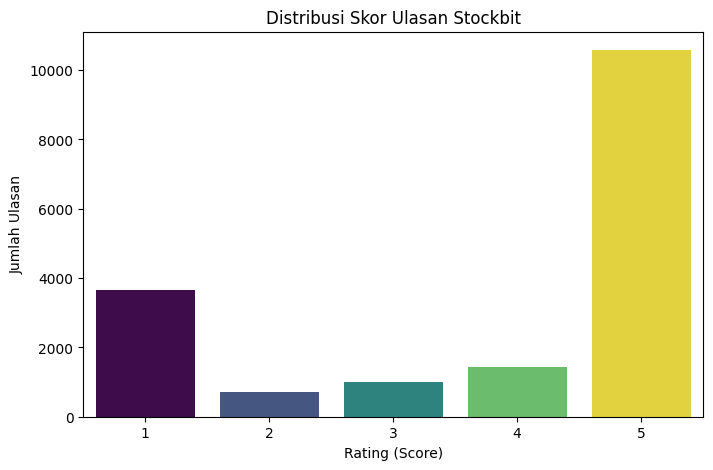

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_stockbit, x='score', hue='score', palette='viridis', legend=False)
plt.title('Distribusi Skor Ulasan Stockbit')
plt.xlabel('Rating (Score)')
plt.ylabel('Jumlah Ulasan')
plt.show()

## 3. Analisis Panjang Karakter Ulasan
Melihat seberapa panjang ulasan yang biasanya diberikan pengguna.

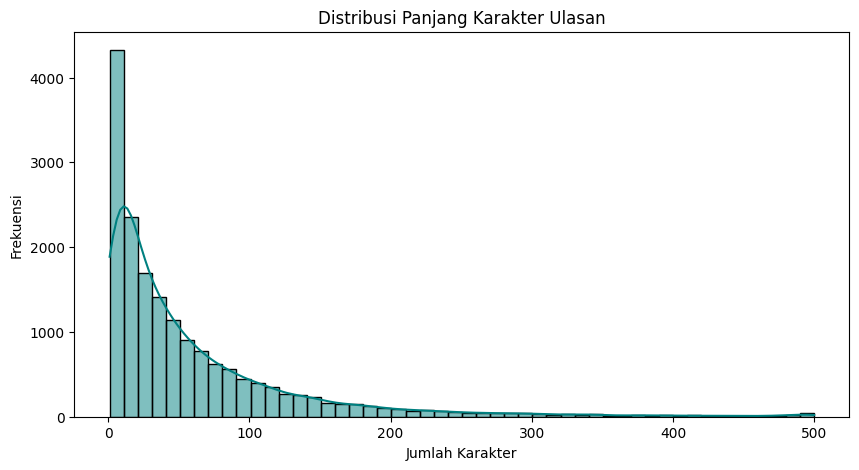

In [19]:
df_stockbit['content_length'] = df_stockbit['content'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df_stockbit['content_length'], bins=50, kde=True, color='teal')
plt.title('Distribusi Panjang Karakter Ulasan')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

## 4. Word Cloud
Visualisasi kata-kata yang paling sering muncul dalam ulasan.

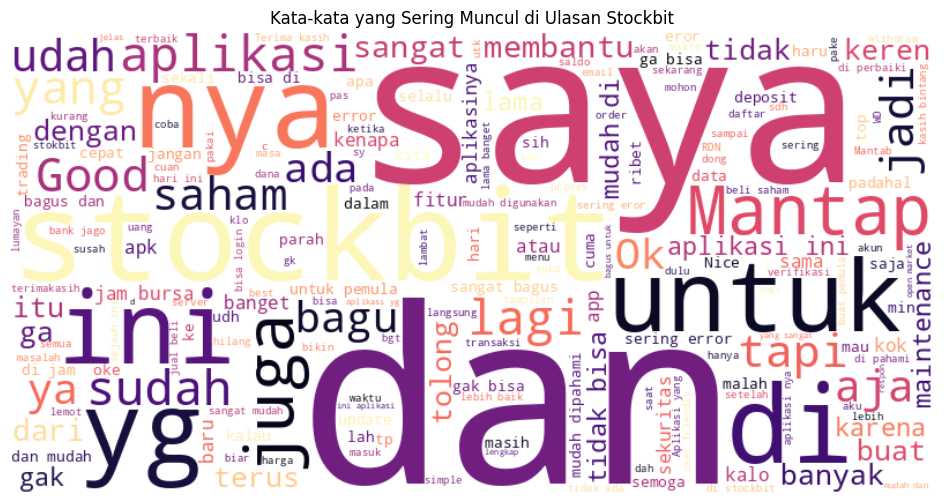

In [20]:
text = ' '.join(str(content) for content in df_stockbit['content'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata-kata yang Sering Muncul di Ulasan Stockbit')
plt.show()

## 5. Tren Ulasan dari Waktu ke Waktu
Menganalisis pertumbuhan jumlah ulasan per bulan.

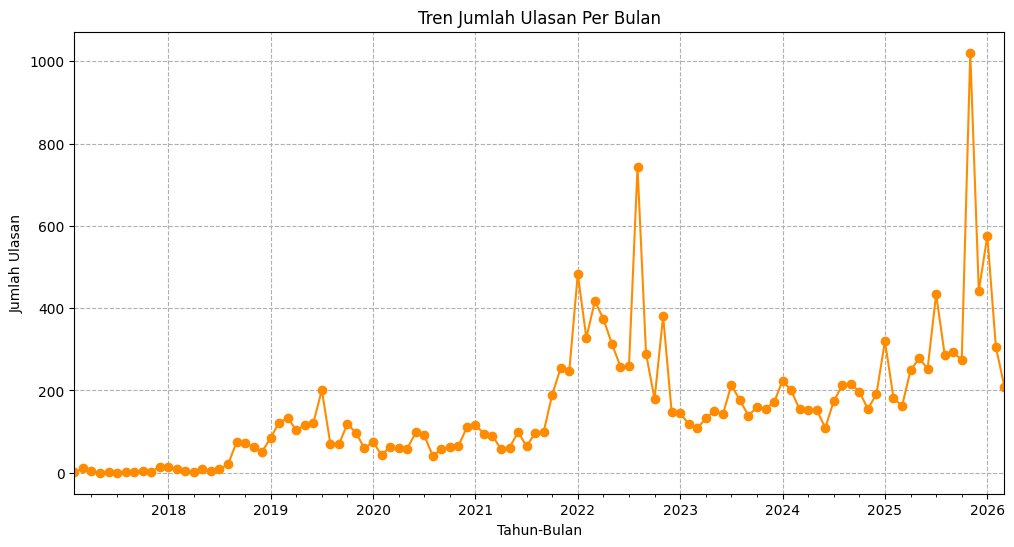

In [21]:
df_stockbit['at'] = pd.to_datetime(df_stockbit['at'])

plt.figure(figsize=(12, 6))
df_stockbit.set_index('at').resample('ME').size().plot(marker='o', color='darkorange')
plt.title('Tren Jumlah Ulasan Per Bulan')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Jumlah Ulasan')
plt.grid(True, linestyle='--')
plt.show()